In [1]:
# prompt: mount drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

# Update the path if needed, based on your drive mount location
fake_df = pd.read_csv('/content/drive/MyDrive/fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/true.csv')

# Add a target column
fake_df['label'] = 0  # Fake
true_df['label'] = 1  # True

# Combine datasets
df = pd.concat([fake_df, true_df]).reset_index(drop=True)

# Shuffle the combined dataframe
df = df.sample(frac=1).reset_index(drop=True)

df.head()


,title,text,subject,date,label
0,Trump-Loving KKK Leader’s Bloated Corpse Pull...,The body of Ku Klux Klan Imperial Wizard Frank...,News,"February 12, 2017",0
1,UK's May picks Brexiteer to replace scandal-hi...,LONDON (Reuters) - Theresa May appointed a str...,worldnews,"November 9, 2017",1
2,(VIDEO) Female College Students Protesting Bec...,21st Century Wire says US college students con...,US_News,"November 11, 2016",0
3,Boiler Room #95 – Weapons of Mass Penetration,Tune in to the Alternate Current Radio Network...,Middle-east,"February 3, 2017",0
4,Ben Carson Makes BOLD Claim That He’d Be The ...,One thing in life you never want to do is pret...,News,"February 23, 2016",0


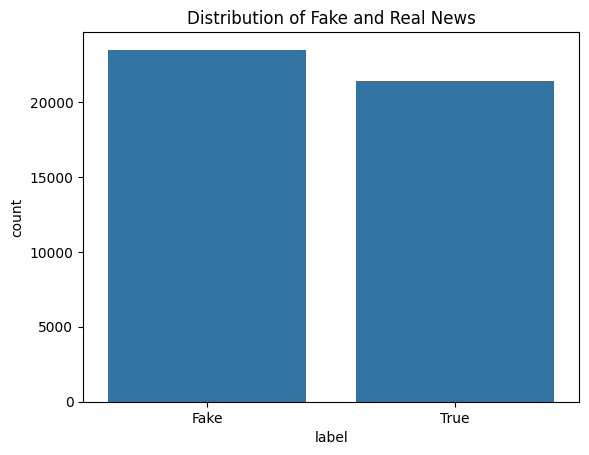

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None

Null Values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64


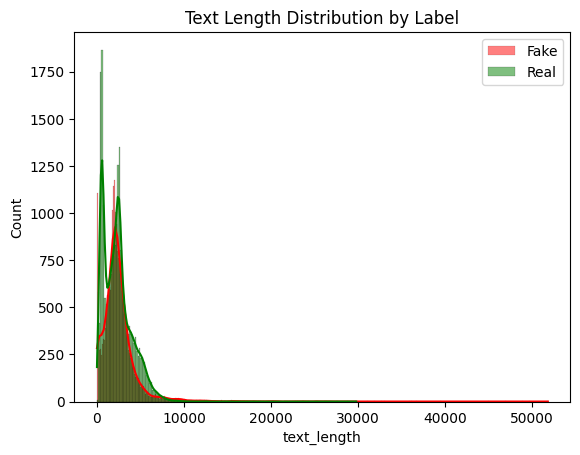

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Label distribution
sns.countplot(x='label', data=df)
plt.title('Distribution of Fake and Real News')
plt.xticks([0,1], ['Fake', 'True'])
plt.show()

# Dataset info
print(df.info())
print("\nNull Values:\n", df.isnull().sum())

# Sample lengths
df['text_length'] = df['text'].apply(len)
sns.histplot(df[df['label'] == 0]['text_length'], color='red', label='Fake', kde=True)
sns.histplot(df[df['label'] == 1]['text_length'], color='green', label='Real', kde=True)
plt.legend()
plt.title('Text Length Distribution by Label')
plt.show()


Mounted at /content/drive


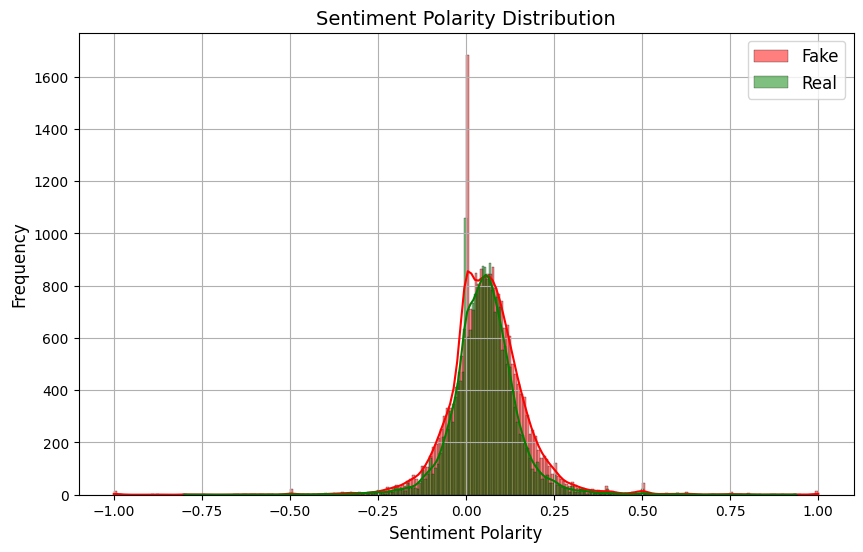

In [3]:
from IPython import get_ipython
from IPython.display import display
# %%
# prompt: mount drive

from google.colab import drive
drive.mount('/content/drive')

# %%
import pandas as pd

# Update the path if needed, based on your drive mount location
fake_df = pd.read_csv('/content/drive/MyDrive/fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/true.csv')

# Add a target column
fake_df['label'] = 0  # Fake
true_df['label'] = 1  # True

# Combine datasets
df = pd.concat([fake_df, true_df]).reset_index(drop=True)

# Shuffle the combined dataframe
df = df.sample(frac=1).reset_index(drop=True)

df.head()
# %%
!pip install textblob
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns


# Apply sentiment polarity
df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Plot sentiment distribution
plt.figure(figsize=(10, 6))  # Adjust figure size for better visualization
sns.histplot(df[df['label'] == 0]['sentiment'], color='red', label='Fake', kde=True)
sns.histplot(df[df['label'] == 1]['sentiment'], color='green', label='Real', kde=True)
plt.title('Sentiment Polarity Distribution', fontsize=14)  # Increase title font size
plt.xlabel('Sentiment Polarity', fontsize=12)  # Add x-axis label
plt.ylabel('Frequency', fontsize=12)  # Add y-axis label
plt.legend(fontsize=12)  # Increase legend font size
plt.grid(True)  # Add grid for better readability
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Logistic Regression model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9841870824053452

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      4660
           1       0.98      0.99      0.98      4320

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



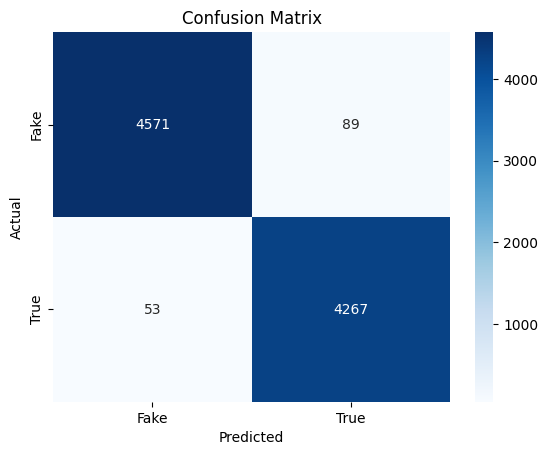

In [5]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


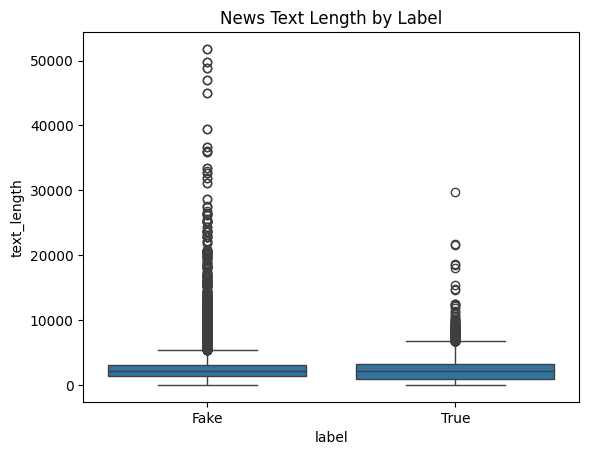

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# ... (other code for data loading and preprocessing) ...

# Calculate text length
df['text_length'] = df['text'].apply(len)

# Create boxplot
sns.boxplot(x='label', y='text_length', data=df)
plt.title('News Text Length by Label')
plt.xticks([0,1], ['Fake', 'True'])
plt.show()

In [10]:
def predict_news(text):
    text_tfidf = vectorizer.transform([text])
    prediction = model.predict(text_tfidf)[0]
    if prediction == 0:
        return "🔴 This news is likely *Fake*"
    else:
        return "🟢 This news is likely *Real*"


In [11]:
# Example input
user_input = input("Paste your news article here:\n")
print(predict_news(user_input))


Paste your news article here:
Prime Minister announces a new vaccine breakthrough in response to recent pandemic
🟢 This news is likely *Real*


In [12]:
# Example input
user_input = input("Paste your news article here:\n")
print(predict_news(user_input))


Paste your news article here:
NASA has confirmed that Earth will experience six days of total darkness from December 16 to December 22 due to a solar storm. This rare event, caused by planetary alignment, will reduce 90% sunlight reaching Earth. President Obama has already been briefed, and NASA urges people not to panic
🔴 This news is likely *Fake*
